# 7-Class 학습법 탐색 노트북
`train_resnet_7class_mp.py`를 여러 설정으로 실행하고 history/최종 성능을 비교합니다.

In [ ]:
import sys, json, subprocess
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

BASE = Path(r"c:\\Users\\ldy34\\Desktop\\Face")
ML = BASE / "ML"
VENV_PY = BASE / ".venv" / "Scripts" / "python.exe"
TRAIN_PY = ML / "train_resnet_7class_mp.py"
EXP_DIR = ML / "experiments_7class"
EXP_DIR.mkdir(exist_ok=True)

print("Current kernel:", sys.executable)
print("Trainer exists:", TRAIN_PY.exists())
print("Experiment dir:", EXP_DIR)

Current kernel: c:\Users\ldy34\Desktop\Face\.venv\Scripts\python.exe
Trainer exists: True
Experiment dir: c:\Users\ldy34\Desktop\Face\ML\experiments_7class


In [2]:
# 실험 설정
COMMON = {
    "base_dir": str(BASE / "video"),
    "batch_size": 256,
    "test_size": 0.15,
    "workers": 8,
    "max_per_zip": 5000,
}

EXPERIMENTS = [
    {"name": "baseline_e200_lr1e3", "epochs": 200, "lr": 1e-3, "seed": 42},
    {"name": "lr5e4_e200", "epochs": 200, "lr": 5e-4, "seed": 42},
    {"name": "lr3e4_e240", "epochs": 240, "lr": 3e-4, "seed": 42},
    {"name": "seed7_e200_lr1e3", "epochs": 200, "lr": 1e-3, "seed": 7},
    {"name": "seed123_e200_lr1e3", "epochs": 200, "lr": 1e-3, "seed": 123}
]

EXPERIMENTS

[{'name': 'baseline_e200_lr1e3', 'epochs': 200, 'lr': 0.001, 'seed': 42},
 {'name': 'lr5e4_e200', 'epochs': 200, 'lr': 0.0005, 'seed': 42},
 {'name': 'lr3e4_e240', 'epochs': 240, 'lr': 0.0003, 'seed': 42},
 {'name': 'seed7_e200_lr1e3', 'epochs': 200, 'lr': 0.001, 'seed': 7},
 {'name': 'seed123_e200_lr1e3', 'epochs': 200, 'lr': 0.001, 'seed': 123}]

In [3]:
# 실험 실행
def run_one(exp):
    out_model = EXP_DIR / f"{exp['name']}.pth"
    cmd = [
        str(VENV_PY), str(TRAIN_PY),
        "--base-dir", COMMON["base_dir"],
        "--epochs", str(exp["epochs"]),
        "--batch-size", str(COMMON["batch_size"]),
        "--lr", str(exp["lr"]),
        "--test-size", str(COMMON["test_size"]),
        "--max-per-zip", str(COMMON["max_per_zip"]),
        "--workers", str(COMMON["workers"]),
        "--seed", str(exp["seed"]),
        "--out", str(out_model)
    ]
    print("RUN:", " ".join(cmd))
    subprocess.run(cmd, cwd=str(BASE), check=True)
    hist = out_model.with_name(out_model.stem + "_history.json")
    return out_model, hist

results_files = []
for exp in EXPERIMENTS:
    model_path, hist_path = run_one(exp)
    results_files.append((exp, model_path, hist_path))

print("Done runs:", len(results_files))

RUN: c:\Users\ldy34\Desktop\Face\.venv\Scripts\python.exe c:\Users\ldy34\Desktop\Face\ML\train_resnet_7class_mp.py --base-dir c:\Users\ldy34\Desktop\Face\video --epochs 200 --batch-size 256 --lr 0.001 --test-size 0.15 --max-per-zip 5000 --workers 8 --seed 42 --out c:\Users\ldy34\Desktop\Face\ML\experiments_7class\baseline_e200_lr1e3.pth
RUN: c:\Users\ldy34\Desktop\Face\.venv\Scripts\python.exe c:\Users\ldy34\Desktop\Face\ML\train_resnet_7class_mp.py --base-dir c:\Users\ldy34\Desktop\Face\video --epochs 200 --batch-size 256 --lr 0.0005 --test-size 0.15 --max-per-zip 5000 --workers 8 --seed 42 --out c:\Users\ldy34\Desktop\Face\ML\experiments_7class\lr5e4_e200.pth
RUN: c:\Users\ldy34\Desktop\Face\.venv\Scripts\python.exe c:\Users\ldy34\Desktop\Face\ML\train_resnet_7class_mp.py --base-dir c:\Users\ldy34\Desktop\Face\video --epochs 240 --batch-size 256 --lr 0.0003 --test-size 0.15 --max-per-zip 5000 --workers 8 --seed 42 --out c:\Users\ldy34\Desktop\Face\ML\experiments_7class\lr3e4_e240.pth

In [4]:
# 결과 요약 테이블
rows = []
for exp, model_path, hist_path in results_files:
    with open(hist_path, "r", encoding="utf-8") as f:
        h = json.load(f)
    best_idx = int(max(range(len(h['test_acc'])), key=lambda i: h['test_acc'][i]))
    rows.append({
        "name": exp['name'],
        "epochs": exp['epochs'],
        "lr": exp['lr'],
        "seed": exp['seed'],
        "best_val_acc": h['test_acc'][best_idx],
        "val_loss_at_best": h['test_loss'][best_idx],
        "final_val_acc": h['test_acc'][-1],
        "final_val_loss": h['test_loss'][-1],
        "best_epoch": best_idx + 1,
        "history": str(hist_path)
    })

df = pd.DataFrame(rows).sort_values(["best_val_acc", "final_val_acc"], ascending=False)
display(df)
df.to_csv(EXP_DIR / "summary.csv", index=False, encoding="utf-8-sig")
print("saved:", EXP_DIR / "summary.csv")

,name,epochs,lr,seed,best_val_acc,val_loss_at_best,final_val_acc,final_val_loss,best_epoch,history
0,baseline_e200_lr1e3,200,0.0010,42,0.814000,0.830570,0.812762,0.831809,195,c:\Users\ldy34\Desktop\Face\ML\experiments_7cl...
1,lr5e4_e200,200,0.0005,42,0.813714,0.817020,0.812857,0.814933,177,c:\Users\ldy34\Desktop\Face\ML\experiments_7cl...
3,seed7_e200_lr1e3,200,0.0010,7,0.812429,0.852982,0.811810,0.850496,193,c:\Users\ldy34\Desktop\Face\ML\experiments_7cl...
2,lr3e4_e240,240,0.0003,42,0.811810,0.815787,0.811190,0.821977,230,c:\Users\ldy34\Desktop\Face\ML\experiments_7cl...
4,seed123_e200_lr1e3,200,0.0010,123,0.811381,0.806125,0.809143,0.822135,165,c:\Users\ldy34\Desktop\Face\ML\experiments_7cl...


saved: c:\Users\ldy34\Desktop\Face\ML\experiments_7class\summary.csv


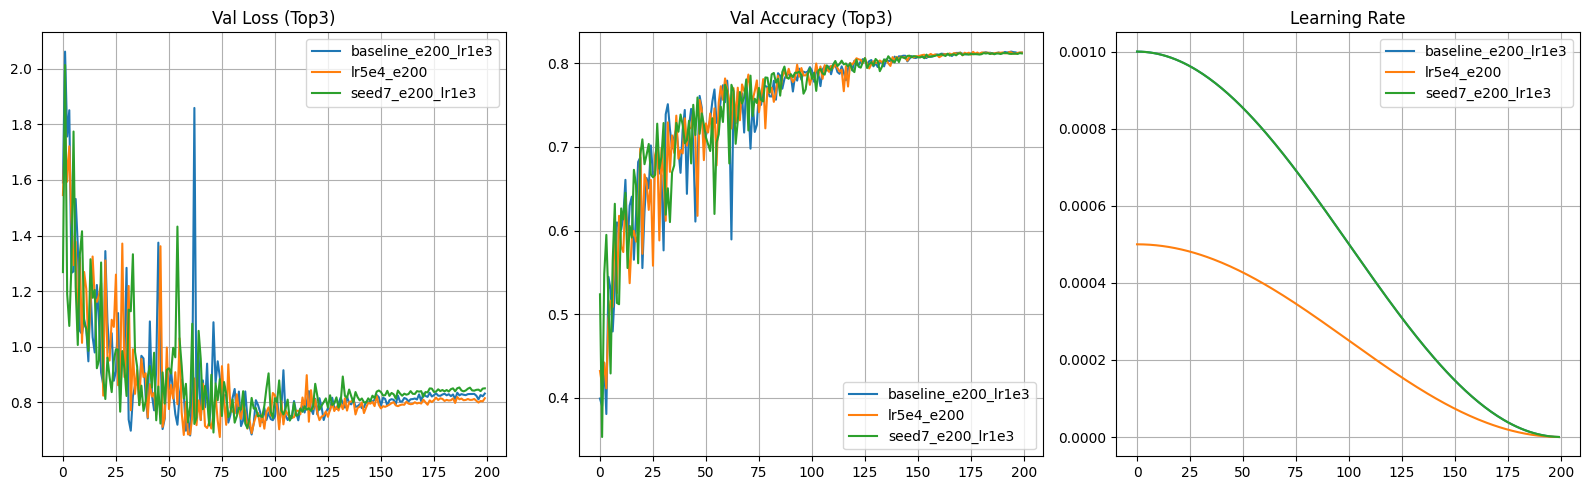

In [5]:
# 상위 실험 곡선 비교
top = df.head(3)['name'].tolist()
plt.figure(figsize=(16,5))

plt.subplot(1,3,1)
for name in top:
    row = df[df['name'] == name].iloc[0]
    with open(row['history'], 'r', encoding='utf-8') as f:
        h = json.load(f)
    plt.plot(h['test_loss'], label=name)
plt.title('Val Loss (Top3)'); plt.grid(True); plt.legend()

plt.subplot(1,3,2)
for name in top:
    row = df[df['name'] == name].iloc[0]
    with open(row['history'], 'r', encoding='utf-8') as f:
        h = json.load(f)
    plt.plot(h['test_acc'], label=name)
plt.title('Val Accuracy (Top3)'); plt.grid(True); plt.legend()

plt.subplot(1,3,3)
for name in top:
    row = df[df['name'] == name].iloc[0]
    with open(row['history'], 'r', encoding='utf-8') as f:
        h = json.load(f)
    plt.plot(h['lr'], label=name)
plt.title('Learning Rate'); plt.grid(True); plt.legend()

plt.tight_layout()
plt.show()